# ResNet-18 + DenseNet-121 Hybrid

In [68]:
import os, subprocess
from pathlib import Path

# ── Find AD/CN/MCI root ─────────────────────────────────────────────────────

GDRIVE_FILE_ID = '1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz'
WORK_DIR = Path('/kaggle/working')

TARGET_CLASSES = {'AD', 'CN', 'MCI'}

def find_adni_root(search_roots):
    """
    Check at most 2 levels deep (root itself, then its direct children).
    This avoids picking up the tensor-cache directory
    (/kaggle/working/preprocessed_*/train/AD …) which is 3 levels deep.
    """
    for sr in search_roots:
        sr = Path(sr)
        if not sr.exists():
            continue
        try:
            subdirs = {d for d in os.listdir(sr) if os.path.isdir(sr / d)}
            if TARGET_CLASSES.issubset(subdirs):
                return str(sr)
        except PermissionError:
            pass
        try:
            for sub in sorted(os.listdir(sr)):
                sub_path = sr / sub
                if not sub_path.is_dir():
                    continue
                try:
                    subdirs = {d for d in os.listdir(sub_path) if (sub_path / d).is_dir()}
                    if TARGET_CLASSES.issubset(subdirs):
                        return str(sub_path)
                except PermissionError:
                    pass
        except PermissionError:
            pass
    return None

# --- Search /kaggle/input first (Kaggle dataset attached via "Add Data") ---
ADNI_DIR = find_adni_root(['/kaggle/input'])

# --- Then /kaggle/working (previous gdown download) ---
if ADNI_DIR is None:
    ADNI_DIR = find_adni_root([WORK_DIR])

# --- Download if still not found ---
if ADNI_DIR is None:
    ADNI_ZIP_PATH = WORK_DIR / 'adni_dataset.zip'
    print('Dataset not found locally — downloading via gdown ...')
    subprocess.run(['pip', 'install', '-q', 'gdown'], check=True)
    import gdown
    gdown.download(f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}', str(ADNI_ZIP_PATH), quiet=False)
    import zipfile
    with zipfile.ZipFile(str(ADNI_ZIP_PATH), 'r') as zf:
        zf.extractall(str(WORK_DIR))
    ADNI_ZIP_PATH.unlink(missing_ok=True)
    ADNI_DIR = find_adni_root([WORK_DIR])

if ADNI_DIR is None:
    raise RuntimeError(
        'Could not find a directory containing AD, CN, MCI subfolders.\n'
        'Options:\n'
        '  1. Add the Alzheimer dataset via Kaggle "Add Data" (fastest).\n'
        '  2. Set GDRIVE_FILE_ID to your own Google Drive zip.\n'
        '  3. Manually set ADNI_DIR below.'
    )

print(f'ADNI_DIR = {ADNI_DIR}')

for cls in sorted(TARGET_CLASSES):
    cls_path = os.path.join(ADNI_DIR, cls)
    n = sum(len(f) for _, _, f in os.walk(cls_path)) if os.path.isdir(cls_path) else 0
    print(f'  {cls}: ~{n} files')

ADNI_DIR = /kaggle/working/adni_nifti_preprocessed
  AD: ~1434 files
  CN: ~2341 files
  MCI: ~4737 files


In [69]:
%pip install -q captum lime scikit-image shap

Note: you may need to restart the kernel to use updated packages.


In [70]:
import csv, json, random, shutil, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
import seaborn as sns
from collections import Counter
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import (
    resnet18, ResNet18_Weights,
    densenet121, DenseNet121_Weights,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_fscore_support, f1_score,
)

import torch._dynamo
torch._dynamo.config.suppress_errors = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [71]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_ROOT = ADNI_DIR
OUTPUT_DIR = '/kaggle/working/preprocessed_hybrid_rn18_dn121'
CKPT_DIR   = '/kaggle/working/checkpoints_hybrid_rn18_dn121'
os.makedirs(CKPT_DIR, exist_ok=True)

# ── Data ────────────────────────────────────────────────────────────────────
IMAGE_SIZE    = 224
TRAIN_RATIO   = 0.80
BATCH_SIZE    = 32
NUM_WORKERS   = 2
PREPROCESS_MODE = 'gray3'

# ── Two-phase training budget ───────────────────────────────────────────────
PHASE_A_EPOCHS  = 12
PHASE_B_EPOCHS  = 30
PATIENCE        = 10
WARMUP_EPOCHS   = 2
LR_MIN          = 1e-6

# ── Discriminative LRs ──────────────────────────────────────────────────────
LR_HEAD_A      = 3e-3
LR_HEAD_B      = 1e-3
LR_BACKBONE_B  = 1e-4
WEIGHT_DECAY   = 5e-5
GRAD_CLIP_NORM = 1.0

# ── Head architecture ────────────────────────────────────────────────────────
HEAD_HIDDEN    = 384
HEAD_USE_BN    = True
DROPOUT        = 0.30

# ── Loss & label smoothing ──────────────────────────────────────────────────
LABEL_SMOOTHING       = 0.05
USE_CLASS_WEIGHTED_CE = True
USE_WEIGHTED_SAMPLER  = False

# ── Augmentation ────────────────────────────────────────────────────────────
USE_RANDAUGMENT = True
RANDAUG_N       = 2
RANDAUG_M       = 7
RANDOM_ERASING  = 0.20

# ── Test-time augmentation ───────────────────────────────────────────────────
TTA_HFLIP = True

# ── Backbone freeze (Phase B overrides to unfreeze last block) ───────────────
FREEZE_BACKBONES    = True
UNFREEZE_LAST_BLOCK = True

# ── XAI ─────────────────────────────────────────────────────────────────────
GRADCAM_TARGET  = 'resnet'
SHAP_BG_SAMPLES = 16
LIME_NUM_SAMPLES = 100

# ── ImageNet stats ──────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
VALID_EXTS    = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d)) and d in ('AD', 'CN', 'MCI')
])
if not CLASS_NAMES:
    CLASS_NAMES = sorted([d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))])
print(f'Classes: {CLASS_NAMES} | IMAGE_SIZE={IMAGE_SIZE} | PREPROCESS_MODE={PREPROCESS_MODE}')
print(f'Phase A={PHASE_A_EPOCHS} ep lr={LR_HEAD_A} | Phase B={PHASE_B_EPOCHS} ep lr_head={LR_HEAD_B} lr_bb={LR_BACKBONE_B}')
print(f'HEAD_HIDDEN={HEAD_HIDDEN} HEAD_USE_BN={HEAD_USE_BN} DROPOUT={DROPOUT} | USE_CLASS_WEIGHTED_CE={USE_CLASS_WEIGHTED_CE}')

Classes: ['AD', 'CN', 'MCI'] | IMAGE_SIZE=224 | PREPROCESS_MODE=gray3
Phase A=12 ep lr=0.003 | Phase B=30 ep lr_head=0.001 lr_bb=0.0001
HEAD_HIDDEN=384 HEAD_USE_BN=True DROPOUT=0.3 | USE_CLASS_WEIGHTED_CE=True


In [72]:
all_paths, all_labels = [], []
for idx, cls in enumerate(CLASS_NAMES):
    cls_root = os.path.join(DATA_ROOT, cls)
    if not os.path.isdir(cls_root):
        print(f'  [WARN] class dir not found: {cls_root}')
        continue
    for dirpath, _, fnames in os.walk(cls_root):
        for fname in fnames:
            if os.path.splitext(fname)[1].lower() in VALID_EXTS:
                all_paths.append(os.path.join(dirpath, fname))
                all_labels.append(idx)

print(f'Total slices: {len(all_paths)}')
for i, c in enumerate(CLASS_NAMES):
    print(f'  {c}: {all_labels.count(i)}')

if len(all_paths) == 0:
    from collections import Counter as _Ctr
    ext_ctr = _Ctr()
    for dirpath, _, fnames in os.walk(DATA_ROOT):
        for fname in fnames:
            ext_ctr[os.path.splitext(fname)[1].lower()] += 1
    print(f'\n[DIAG] DATA_ROOT = {DATA_ROOT}')
    print(f'[DIAG] All file extensions under DATA_ROOT: {dict(ext_ctr.most_common(15))}')
    print(f'[DIAG] VALID_EXTS = {VALID_EXTS}')
    print('[DIAG] If images have a different extension, add it to VALID_EXTS in the config cell.')
    raise RuntimeError(
        f'No images found under {DATA_ROOT}.\n'
        'Likely causes:\n'
        '  1. Dataset not downloaded — re-run the gdown cell.\n'
        '  2. Images use an extension not in VALID_EXTS (see diag above).\n'
        '  3. DATA_ROOT points to the wrong directory — check ADNI_DIR output above.'
    )

Total slices: 8512
  AD: 1434
  CN: 2341
  MCI: 4737


In [73]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=1 - TRAIN_RATIO, stratify=all_labels, random_state=SEED)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=SEED)
print(f'Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}')

tr, va, te = set(train_paths), set(val_paths), set(test_paths)
print(f'Overlap train-val {len(tr&va)} | train-test {len(tr&te)} | val-test {len(va&te)}')
assert not (tr & va) and not (tr & te) and not (va & te), 'Path leak detected!'
print('No path overlap — OK')

print('Class distribution:')
for name, lbls in [('train', train_labels), ('val', val_labels), ('test', test_labels)]:
    print(f'  {name}: {dict(sorted(Counter(lbls).items()))}')

Train: 6809 | Val: 851 | Test: 852
Overlap train-val 0 | train-test 0 | val-test 0
No path overlap — OK
Class distribution:
  train: {0: 1147, 1: 1873, 2: 3789}
  val: {0: 143, 1: 234, 2: 474}
  test: {0: 144, 1: 234, 2: 474}


In [74]:
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)
filename_usage = {}

def save_tensors(paths, labels, split_name):
    split_dir = os.path.join(OUTPUT_DIR, split_name)
    for path, label in tqdm(zip(paths, labels), total=len(paths), desc=f'Save {split_name}'):
        cls_name = CLASS_NAMES[label]
        out_dir  = os.path.join(split_dir, cls_name)
        os.makedirs(out_dir, exist_ok=True)
        base   = os.path.splitext(os.path.basename(path))[0]
        parent = os.path.basename(os.path.dirname(path))
        key    = f'{cls_name}_{parent}_{base}'
        if key in filename_usage:
            filename_usage[key] += 1
            fname = f'{parent}_{base}_dup{filename_usage[key]}.pt'
        else:
            filename_usage[key] = 0
            fname = f'{parent}_{base}.pt'
        out_path = os.path.join(out_dir, fname)
        if os.path.exists(out_path):
            continue
        if PREPROCESS_MODE == 'rgb':
            img = Image.open(path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
            t   = (transforms.ToTensor()(img) * 255).byte()
        elif PREPROCESS_MODE == 'gray3':
            img = Image.open(path).convert('L').resize((IMAGE_SIZE, IMAGE_SIZE))
            t   = (transforms.ToTensor()(img) * 255).byte().repeat(3, 1, 1)
        else:
            raise ValueError('PREPROCESS_MODE must be rgb or gray3')
        torch.save(t, out_path)

save_tensors(train_paths, train_labels, 'train')
save_tensors(val_paths,   val_labels,   'val')
save_tensors(test_paths,  test_labels,  'test')
print('Cache done.')

Save test: 100%|██████████| 852/852 [00:02<00:00, 423.55it/s]

Cache done.


In [75]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

_rand_aug = transforms.RandAugment(num_ops=RANDAUG_N, magnitude=RANDAUG_M) if USE_RANDAUGMENT else None
_erasing  = transforms.RandomErasing(p=RANDOM_ERASING, scale=(0.02, 0.12)) if RANDOM_ERASING > 0 else None

def apply_train_augment(t_byte):
    """t_byte: uint8 tensor (3, H, W). Returns float (3, H, W), normalized."""
    t = t_byte.clone()
    t = transforms.RandomHorizontalFlip(p=0.5)(t)
    if _rand_aug is not None:
        t = _rand_aug(t)
    t = t.float() / 255.0
    t = transforms.ColorJitter(brightness=0.15, contrast=0.15)(t)
    t = normalize(t)
    if _erasing is not None:
        t = _erasing(t)
    return t

class AlzheimerDataset(Dataset):
    def __init__(self, split_dir, class_names, augment=False):
        self.samples, self.augment = [], augment
        for idx, cls in enumerate(class_names):
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.endswith('.pt'):
                    self.samples.append((os.path.join(cls_dir, fname), idx))
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        pth, lab = self.samples[i]
        t = torch.load(pth, weights_only=True)
        if self.augment:
            return apply_train_augment(t), lab
        return normalize(t.float() / 255.0), lab
    def get_labels(self): return [s[1] for s in self.samples]

train_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, 'train'), CLASS_NAMES, augment=True)
val_ds   = AlzheimerDataset(os.path.join(OUTPUT_DIR, 'val'),   CLASS_NAMES)
test_ds  = AlzheimerDataset(os.path.join(OUTPUT_DIR, 'test'),  CLASS_NAMES)
print(f'Dataset sizes — Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

cc  = Counter(train_ds.get_labels())
print(f'Training class distribution: {dict(sorted(cc.items()))}')

try:
    nw = int(NUM_WORKERS)
except NameError:
    nw = min(2, os.cpu_count() or 1)
_pin     = device.type == 'cuda'
_persist = nw > 0

if USE_WEIGHTED_SAMPLER:
    wts     = [1.0 / cc[l] for l in train_ds.get_labels()]
    sampler = WeightedRandomSampler(wts, len(wts), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=nw, pin_memory=_pin, persistent_workers=_persist)
    print('Using WeightedRandomSampler')
else:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=nw, pin_memory=_pin, persistent_workers=_persist)
    print('Using shuffle=True + class-weighted CE')

print(f'DataLoader: num_workers={nw}, pin_memory={_pin}')
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=nw, pin_memory=_pin, persistent_workers=_persist)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=nw, pin_memory=_pin, persistent_workers=_persist)

Dataset sizes — Train: 6809 | Val: 851 | Test: 852
Training class distribution: {0: 1147, 1: 1873, 2: 3789}
Using shuffle=True + class-weighted CE
DataLoader: num_workers=2, pin_memory=True


In [76]:
def _make_head(in_dim, hidden, num_classes, dropout, use_bn):
    """BN-anchored MLP head. BatchNorm1d compensates BN-eval mismatch on MRI features."""
    layers = [nn.Dropout(dropout)]
    hh = int(hidden) if hidden else 0
    if hh > 0:
        layers += [nn.Linear(in_dim, hh)]
        if use_bn:
            layers += [nn.BatchNorm1d(hh)]
        layers += [nn.GELU(),
                   nn.Dropout(max(0.0, dropout * 0.5)),
                   nn.Linear(hh, num_classes)]
    else:
        layers += [nn.Linear(in_dim, num_classes)]
    return nn.Sequential(*layers)

class ResNetDenseNetHybrid(nn.Module):
    """Frozen ResNet-18 (512-D) + frozen DenseNet-121 (1024-D) → trainable head."""
    def __init__(self, num_classes, dropout=0.30, head_hidden=384, head_use_bn=True,
                 freeze_backbones=True):
        super().__init__()
        r = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        r.fc = nn.Identity()
        d = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        d.classifier = nn.Identity()
        self.resnet   = r
        self.densenet = d
        if freeze_backbones:
            for p in self.resnet.parameters():   p.requires_grad = False
            for p in self.densenet.parameters(): p.requires_grad = False
        self.head = _make_head(512 + 1024, head_hidden, num_classes, dropout, head_use_bn)

    def forward(self, x):
        return self.head(torch.cat([self.resnet(x), self.densenet(x)], dim=1))

def build_resnet18_only(num_classes, dropout=0.30, head_hidden=384, head_use_bn=True,
                        freeze_backbones=True):
    """Frozen ResNet-18 baseline with the same BN-anchored MLP head."""
    r = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbones:
        for p in r.parameters(): p.requires_grad = False
    r.fc = _make_head(512, head_hidden, num_classes, dropout, head_use_bn)
    return r

K = len(CLASS_NAMES)
hybrid_model   = ResNetDenseNetHybrid(
    K, dropout=DROPOUT, head_hidden=HEAD_HIDDEN, head_use_bn=HEAD_USE_BN,
    freeze_backbones=FREEZE_BACKBONES,
).to(device)
baseline_model = build_resnet18_only(
    K, dropout=DROPOUT, head_hidden=HEAD_HIDDEN, head_use_bn=HEAD_USE_BN,
    freeze_backbones=FREEZE_BACKBONES,
).to(device)

total_h = sum(p.numel() for p in hybrid_model.parameters())
train_h = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)
total_b = sum(p.numel() for p in baseline_model.parameters())
train_b = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f'Hybrid model   — total params: {total_h:,} | trainable: {train_h:,}')
print(f'Baseline model — total params: {total_b:,} | trainable: {train_b:,}')
print('(Trainable = head only at build time; Phase B will additionally unfreeze last blocks)')

Hybrid model   — total params: 18,722,499 | trainable: 592,131
Baseline model — total params: 11,375,427 | trainable: 198,915
(Trainable = head only at build time; Phase B will additionally unfreeze last blocks)


In [77]:
import math

# ── Loss ─────────────────────────────────────────────────────────────────────
if USE_CLASS_WEIGHTED_CE:
    _counts = Counter(train_ds.get_labels())
    _w = torch.tensor([1.0 / _counts[i] for i in range(K)], dtype=torch.float, device=device)
    _w = _w / _w.sum() * K
    criterion = nn.CrossEntropyLoss(weight=_w, label_smoothing=LABEL_SMOOTHING)
    print(f'Class weights: { {CLASS_NAMES[i]: round(float(_w[i]),3) for i in range(K)} }')
else:
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# ── Freeze / unfreeze helpers ────────────────────────────────────────────────
def freeze_all_but_head(model):
    """Phase A: only head is trainable."""
    for p in model.parameters(): p.requires_grad = False
    head = model.head if hasattr(model, 'head') else model.fc
    for p in head.parameters(): p.requires_grad = True

def unfreeze_last_blocks(model):
    """Phase B: additionally unfreeze last residual/dense block."""
    if hasattr(model, 'densenet'):
        for p in model.resnet.layer4.parameters():                 p.requires_grad = True
        for p in model.densenet.features.denseblock4.parameters(): p.requires_grad = True
        for p in model.densenet.features.norm5.parameters():       p.requires_grad = True
    else:
        for p in model.layer4.parameters():                        p.requires_grad = True

def set_probe_training_mode(model, training: bool, phase_b: bool = False):
    """Keep frozen BN in eval(); only trainable sub-modules go to train()."""
    if not training:
        model.eval(); return
    if hasattr(model, 'densenet'):
        model.train()
        model.resnet.eval()
        model.densenet.eval()
        if phase_b:
            model.resnet.layer4.train(True)
            model.densenet.features.denseblock4.train(True)
            model.densenet.features.norm5.train(True)
        model.head.train(True)
    else:
        model.eval()
        if phase_b:
            model.layer4.train(True)
        model.fc.train(True)

# ── Optimizer with discriminative LRs ───────────────────────────────────────
def build_optimizer(model, lr_head, lr_backbone=None):
    head    = model.head if hasattr(model, 'head') else model.fc
    head_ids = {id(p) for p in head.parameters()}
    head_params = list(head.parameters())
    back_params = [p for p in model.parameters() if p.requires_grad and id(p) not in head_ids]
    groups = [{'params': head_params, 'lr': lr_head}]
    if back_params and lr_backbone:
        groups.append({'params': back_params, 'lr': lr_backbone})
    return optim.AdamW(groups, weight_decay=WEIGHT_DECAY)

# ── Cosine LR + warmup (per-epoch step) ─────────────────────────────────────
def cosine_with_warmup(optimizer, total_epochs, warmup):
    def lr_lambda(epoch):
        if epoch < warmup:
            return (epoch + 1) / max(1, warmup)
        progress = (epoch - warmup) / max(1, total_epochs - warmup)
        return max(LR_MIN / optimizer.param_groups[0]['initial_lr'],
                   0.5 * (1.0 + math.cos(math.pi * progress)))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── Core epoch runner ────────────────────────────────────────────────────────
def run_epoch(loader, model, criterion, optimizer=None, scaler=None, desc='', phase_b=False):
    is_train = optimizer is not None
    set_probe_training_mode(model, is_train, phase_b=phase_b)
    dev_type   = 'cuda' if device.type == 'cuda' else 'cpu'
    total_loss = correct = total = 0
    all_preds, all_labels = [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=dev_type, enabled=(device.type == 'cuda')):
                outputs = model(images)
                loss    = criterion(outputs, labels)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                if GRAD_CLIP_NORM and GRAD_CLIP_NORM > 0:
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(
                        [p for p in model.parameters() if p.requires_grad], GRAD_CLIP_NORM)
                scaler.step(optimizer)
                scaler.update()
            preds       = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            total_loss += loss.item() * labels.size(0)
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / max(total, 1), correct / max(total, 1), all_preds, all_labels

# ── Single-phase train loop ──────────────────────────────────────────────────
def train_phase(model, optimizer, scheduler, n_epochs, ckpt_path,
                phase_name, best_f1_in, phase_b=False):
    scaler       = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
    best_f1      = best_f1_in
    patience_ctr = 0
    history      = {'train_loss': [], 'train_acc': [], 'val_loss': [],
                    'val_acc': [], 'val_macro_f1': [], 'lr': []}
    sep = '=' * 60
    print(f'\n{sep}\n  {phase_name}\n{sep}')
    for epoch in range(1, n_epochs + 1):
        tl, ta, _, _ = run_epoch(train_loader, model, criterion, optimizer, scaler,
                                 desc=f'{phase_name} ep{epoch}/{n_epochs} [train]',
                                 phase_b=phase_b)
        vl, va, vp, vl_true = run_epoch(val_loader, model, criterion,
                                        desc=f'{phase_name} ep{epoch}/{n_epochs} [val]',
                                        phase_b=phase_b)
        mf1    = float(f1_score(vl_true, vp, average='macro', zero_division=0))
        cur_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(tl); history['train_acc'].append(ta)
        history['val_loss'].append(vl);   history['val_acc'].append(va)
        history['val_macro_f1'].append(mf1); history['lr'].append(cur_lr)
        scheduler.step()
        print(f'Epoch {epoch:02d} | lr={cur_lr:.2e} | train loss={tl:.4f} acc={ta*100:.2f}%'
              f' | val loss={vl:.4f} acc={va*100:.2f}% macro-F1={mf1:.4f}')
        if mf1 > best_f1 + 1e-5:
            best_f1 = mf1; patience_ctr = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f'  Best macro-F1={best_f1:.4f} — saved.')
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}.'); break
    return history, best_f1

# ── Two-phase training orchestrator ─────────────────────────────────────────
def train_two_phase(model, name, ckpt_name):
    ckpt_path = os.path.join(CKPT_DIR, ckpt_name)
    freeze_all_but_head(model)
    opt_a   = build_optimizer(model, LR_HEAD_A)
    sched_a = cosine_with_warmup(opt_a, PHASE_A_EPOCHS, WARMUP_EPOCHS)
    hist_a, best_f1 = train_phase(
        model, opt_a, sched_a, PHASE_A_EPOCHS, ckpt_path,
        f'{name} / Phase A (probe)', 0.0, phase_b=False)
    print(f'\nPhase A best val macro-F1: {best_f1:.4f}')
    phase_a_f1 = best_f1

    hist_b = None
    phase_b_f1 = best_f1
    if UNFREEZE_LAST_BLOCK:
        model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
        unfreeze_last_blocks(model)
        opt_b   = build_optimizer(model, LR_HEAD_B, LR_BACKBONE_B)
        sched_b = cosine_with_warmup(opt_b, PHASE_B_EPOCHS, WARMUP_EPOCHS)
        hist_b, best_f1 = train_phase(
            model, opt_b, sched_b, PHASE_B_EPOCHS, ckpt_path,
            f'{name} / Phase B (fine-tune)', best_f1, phase_b=True)
        print(f'\nPhase B best val macro-F1: {best_f1:.4f}')
        phase_b_f1 = best_f1

    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
    model.eval()
    return {'phase_a': hist_a, 'phase_b': hist_b,
            'phase_a_best_f1': phase_a_f1, 'phase_b_best_f1': phase_b_f1}, best_f1

baseline_history, baseline_best_f1 = train_two_phase(
    baseline_model, 'ResNet-18 baseline', 'best_resnet18_only.pt')
hybrid_history, hybrid_best_f1 = train_two_phase(
    hybrid_model, 'ResNet18+DenseNet121 hybrid', 'best_resnet18_dn121_hybrid.pt')

Class weights: {'AD': 1.566, 'CN': 0.959, 'MCI': 0.474}

  ResNet-18 baseline / Phase A (probe)


Epoch 01 | lr=1.50e-03 | train loss=1.1045 acc=39.49% | val loss=1.0819 acc=39.25% macro-F1=0.3876
  Best macro-F1=0.3876 — saved.


Epoch 02 | lr=3.00e-03 | train loss=1.0870 acc=39.62% | val loss=1.0855 acc=42.89% macro-F1=0.4269
  Best macro-F1=0.4269 — saved.


Epoch 03 | lr=3.00e-03 | train loss=1.0603 acc=42.87% | val loss=1.0396 acc=48.53% macro-F1=0.4862
  Best macro-F1=0.4862 — saved.


Epoch 04 | lr=2.93e-03 | train loss=1.0456 acc=43.21% | val loss=1.0036 acc=49.94% macro-F1=0.4739


...

Epoch 26 | lr=7.66e-05 | train loss=0.2661 acc=98.28% | val loss=0.2868 acc=99.29% macro-F1=0.9932


Epoch 27 | lr=4.95e-05 | train loss=0.2711 acc=98.02% | val loss=0.2879 acc=99.29% macro-F1=0.9932


Epoch 28 | lr=2.81e-05 | train loss=0.2674 acc=98.18% | val loss=0.2867 acc=99.41% macro-F1=0.9942


Epoch 29 | lr=1.25e-05 | train loss=0.2674 acc=98.18% | val loss=0.2859 acc=99.65% macro-F1=0.9968
  Best macro-F1=0.9968 — saved.


Epoch 30 | lr=3.14e-06 | train loss=0.2648 acc=98.43% | val loss=0.2866 acc=99.41% macro-F1=0.9942

Phase B best val macro-F1: 0.9968


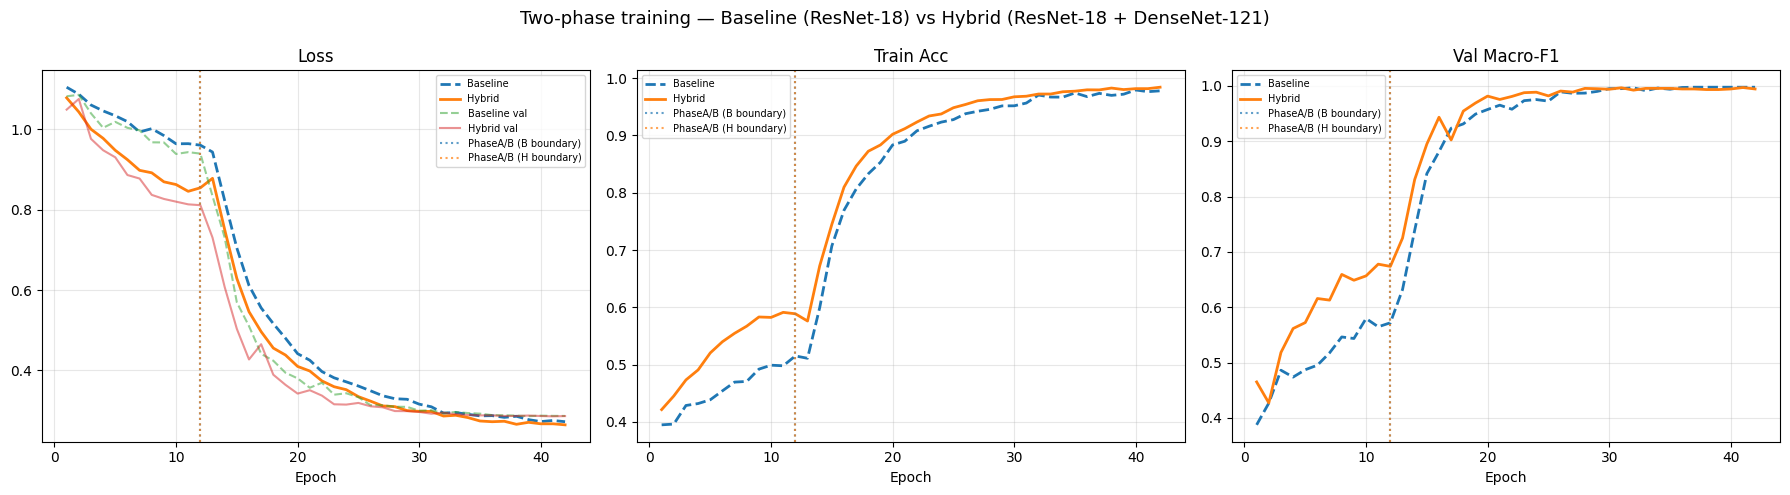

Baseline — Phase A best F1: 0.5796 | Phase B best F1: 0.9974
Hybrid   — Phase A best F1: 0.6778 | Phase B best F1: 0.9968


In [78]:
def stitch_history(hist_dict, keys=('train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_macro_f1', 'lr')):
    """Concatenate Phase A and Phase B history lists for plotting. Returns stitched dict and boundary index."""
    ha = hist_dict['phase_a']
    hb = hist_dict['phase_b']
    stitched = {}
    boundary = len(ha['train_loss']) if ha else 0
    for k in keys:
        a_vals = ha.get(k, []) if ha else []
        b_vals = hb.get(k, []) if hb else []
        stitched[k] = a_vals + b_vals
    return stitched, boundary

bh, b_boundary = stitch_history(baseline_history)
hh, h_boundary = stitch_history(hybrid_history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Two-phase training — Baseline (ResNet-18) vs Hybrid (ResNet-18 + DenseNet-121)',
             fontsize=13)

for ax, key, title in zip(axes,
    ['train_loss',  'train_acc',  'val_macro_f1'],
    ['Loss',        'Train Acc',  'Val Macro-F1']):
    eb = range(1, len(bh[key]) + 1)
    eh = range(1, len(hh[key]) + 1)
    ax.plot(eb, bh[key], '--', label='Baseline', linewidth=2)
    ax.plot(eh, hh[key], '-',  label='Hybrid',   linewidth=2)
    if key == 'train_loss':
        ax.plot(eb, bh['val_loss'], '--', alpha=0.5, label='Baseline val')
        ax.plot(eh, hh['val_loss'], '-',  alpha=0.5, label='Hybrid val')
    for boundary, color, model_label in [
            (b_boundary, 'C0', 'B boundary'), (h_boundary, 'C1', 'H boundary')]:
        if boundary and boundary < max(len(bh[key]), len(hh[key])):
            ax.axvline(x=boundary, color=color, linestyle=':', alpha=0.7,
                       label=f'PhaseA/B ({model_label})')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'training_curves_comparison.png'), dpi=150)
plt.show()

print(f'Baseline — Phase A best F1: {baseline_history["phase_a_best_f1"]:.4f}'
      + (f' | Phase B best F1: {baseline_history["phase_b_best_f1"]:.4f}' if UNFREEZE_LAST_BLOCK else ''))
print(f'Hybrid   — Phase A best F1: {hybrid_history["phase_a_best_f1"]:.4f}'
      + (f' | Phase B best F1: {hybrid_history["phase_b_best_f1"]:.4f}' if UNFREEZE_LAST_BLOCK else ''))

In [79]:
def predict_with_tta(model, loader, use_hflip=True):
    """Return (preds_list, labels_list). Averages logits over original + hflip."""
    model.eval()
    all_preds, all_lbls = [], []
    dev_type = 'cuda' if device.type == 'cuda' else 'cpu'
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=dev_type, enabled=(device.type == 'cuda')):
                logits = model(x)
                if use_hflip:
                    logits = logits + model(torch.flip(x, dims=[-1]))
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_lbls.extend(y.numpy())
    return all_preds, all_lbls

def eval_model(model, name):
    test_preds, test_lbls = predict_with_tta(model, test_loader, use_hflip=TTA_HFLIP)
    print(f'\n=== {name} — Test (TTA_HFLIP={TTA_HFLIP}) ===')
    print(classification_report(test_lbls, test_preds, target_names=CLASS_NAMES, digits=4))
    prec, rec, f1, sup = precision_recall_fscore_support(
        test_lbls, test_preds, average=None, zero_division=0)
    macro_f1 = float(f1_score(test_lbls, test_preds, average='macro', zero_division=0))
    test_acc  = float(np.mean(np.array(test_preds) == np.array(test_lbls)))
    print(f'Macro-F1: {macro_f1:.4f} | Acc: {test_acc*100:.2f}%')
    return test_preds, test_lbls, prec, rec, f1, sup, macro_f1

b_preds, b_lbls, b_prec, b_rec, b_f1, b_sup, b_mf1 = eval_model(baseline_model, 'ResNet-18 baseline')
h_preds, h_lbls, h_prec, h_rec, h_f1, h_sup, h_mf1 = eval_model(hybrid_model,   'ResNet18+DenseNet121 hybrid')


=== ResNet-18 baseline — Test (TTA_HFLIP=True) ===
              precision    recall  f1-score   support

          AD     1.0000    1.0000    1.0000       144
          CN     1.0000    1.0000    1.0000       234
         MCI     1.0000    1.0000    1.0000       474

    accuracy                         1.0000       852
   macro avg     1.0000    1.0000    1.0000       852
weighted avg     1.0000    1.0000    1.0000       852

Macro-F1: 1.0000 | Acc: 100.00%

=== ResNet18+DenseNet121 hybrid — Test (TTA_HFLIP=True) ===
              precision    recall  f1-score   support

          AD     1.0000    1.0000    1.0000       144
          CN     1.0000    1.0000    1.0000       234
         MCI     1.0000    1.0000    1.0000       474

    accuracy                         1.0000       852
   macro avg     1.0000    1.0000    1.0000       852
weighted avg     1.0000    1.0000    1.0000       852

Macro-F1: 1.0000 | Acc: 100.00%


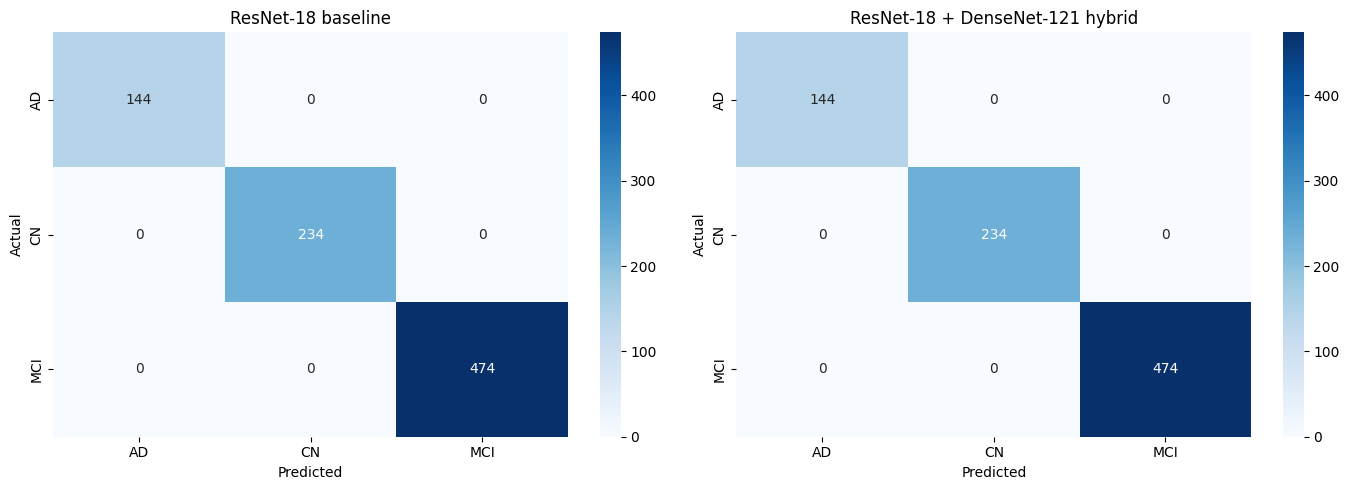

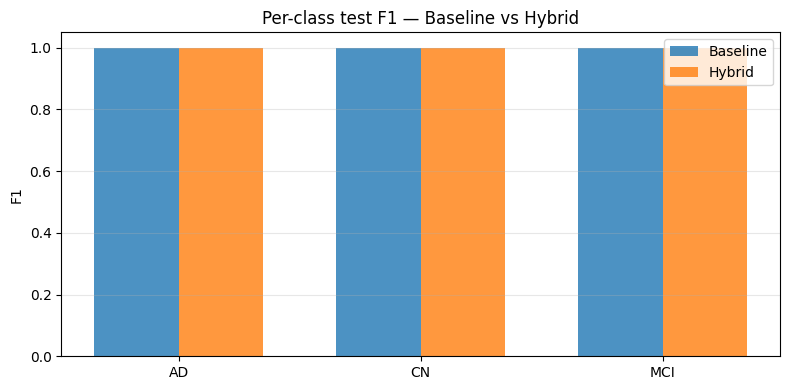

In [80]:
cm_b = confusion_matrix(b_lbls, b_preds)
cm_h = confusion_matrix(h_lbls, h_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm, title in zip(axes, [cm_b, cm_h],
        ['ResNet-18 baseline', 'ResNet-18 + DenseNet-121 hybrid']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
    ax.set_title(title)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'cm_comparison.png'), dpi=150)
plt.show()

x = np.arange(len(CLASS_NAMES))
width = 0.35
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.bar(x - width/2, b_f1, width, label='Baseline', alpha=0.8)
ax2.bar(x + width/2, h_f1, width, label='Hybrid',   alpha=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(CLASS_NAMES)
ax2.set_ylabel('F1'); ax2.set_ylim(0, 1.05)
ax2.set_title('Per-class test F1 — Baseline vs Hybrid')
ax2.legend(); ax2.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'f1_bar_comparison.png'), dpi=150)
plt.show()

In [81]:
results = {
    'protocol': 'Two-phase (linear probe + last-block fine-tune) + Phase2-style 80/10/10 slice split',
    'preprocess_mode': PREPROCESS_MODE,
    'class_names': CLASS_NAMES,
    'freeze_backbones': FREEZE_BACKBONES,
    'unfreeze_last_block': UNFREEZE_LAST_BLOCK,
    'dropout': DROPOUT,
    'head_hidden': HEAD_HIDDEN,
    'head_use_bn': HEAD_USE_BN,
    'label_smoothing': LABEL_SMOOTHING,
    'use_class_weighted_ce': USE_CLASS_WEIGHTED_CE,
    'use_weighted_sampler': USE_WEIGHTED_SAMPLER,
    'use_randaugment': USE_RANDAUGMENT,
    'random_erasing': RANDOM_ERASING,
    'tta_hflip': TTA_HFLIP,
    'phase_a_epochs': PHASE_A_EPOCHS,
    'phase_b_epochs': PHASE_B_EPOCHS,
    'warmup_epochs': WARMUP_EPOCHS,
    'lr_head_a': LR_HEAD_A,
    'lr_head_b': LR_HEAD_B,
    'lr_backbone_b': LR_BACKBONE_B,
    'grad_clip_norm': GRAD_CLIP_NORM,
    'baseline_resnet18': {
        'phase_a_best_f1': float(baseline_history.get('phase_a_best_f1', 0)),
        'phase_b_best_f1': float(baseline_history.get('phase_b_best_f1', 0)),
        'best_val_macro_f1': float(baseline_best_f1),
        'test_macro_f1': float(b_mf1),
        'test_acc': float(np.mean(np.array(b_preds) == np.array(b_lbls))),
        'per_class_f1': {CLASS_NAMES[i]: float(b_f1[i]) for i in range(len(CLASS_NAMES))},
        'confusion_matrix': cm_b.tolist(),
    },
    'hybrid_resnet18_densenet121': {
        'phase_a_best_f1': float(hybrid_history.get('phase_a_best_f1', 0)),
        'phase_b_best_f1': float(hybrid_history.get('phase_b_best_f1', 0)),
        'best_val_macro_f1': float(hybrid_best_f1),
        'test_macro_f1': float(h_mf1),
        'test_acc': float(np.mean(np.array(h_preds) == np.array(h_lbls))),
        'per_class_f1': {CLASS_NAMES[i]: float(h_f1[i]) for i in range(len(CLASS_NAMES))},
        'confusion_matrix': cm_h.tolist(),
    },
}
json_path = os.path.join(CKPT_DIR, 'results_resnet18_dn121_hybrid.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2)
print(f'Saved {json_path}')

csv_path = os.path.join(CKPT_DIR, 'results_resnet18_dn121_hybrid.csv')
with open(csv_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['model', 'metric', 'value'])
    for mname, mres in [('baseline', results['baseline_resnet18']),
                         ('hybrid',   results['hybrid_resnet18_densenet121'])]:
        w.writerow([mname, 'test_acc',      round(mres['test_acc'], 4)])
        w.writerow([mname, 'test_macro_f1', round(mres['test_macro_f1'], 4)])
        for cls, v in mres['per_class_f1'].items():
            w.writerow([mname, f'f1_{cls}', round(v, 4)])
print(f'Saved {csv_path}')

Saved /kaggle/working/checkpoints_hybrid_rn18_dn121/results_resnet18_dn121_hybrid.json
Saved /kaggle/working/checkpoints_hybrid_rn18_dn121/results_resnet18_dn121_hybrid.csv


## XAI — Integrated Gradients, Grad-CAM, SHAP, LIME (hybrid model)

All explanations target the **hybrid ResNet-18 + DenseNet-121** model.


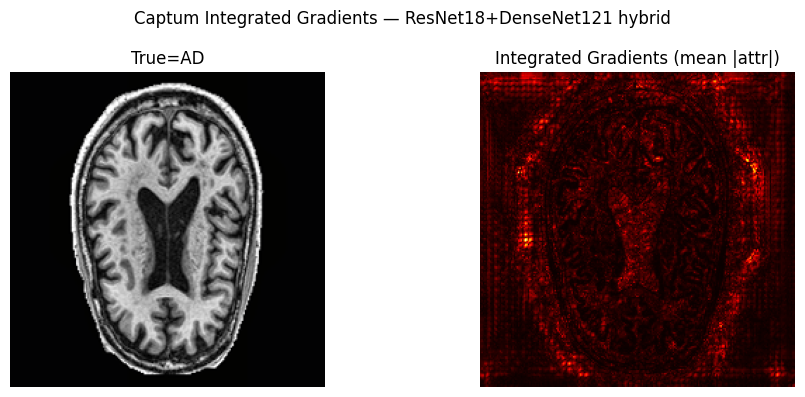

In [82]:
from captum.attr import IntegratedGradients

hybrid_model.eval()
images_xai, labels_xai = next(iter(test_loader))
images_xai = images_xai.to(device)
labels_xai = labels_xai.to(device)
with torch.no_grad():
    preds_xai = hybrid_model(images_xai).argmax(1)

idx_xai = next((i for i in range(images_xai.size(0)) if preds_xai[i] == labels_xai[i]), 0)
xb_ig = images_xai[idx_xai : idx_xai + 1].clone().detach().requires_grad_(True)
yl_ig = labels_xai[idx_xai : idx_xai + 1]

ig = IntegratedGradients(hybrid_model)
attr = ig.attribute(xb_ig, target=yl_ig, n_steps=32)
attr_mag = np.abs(attr.detach().cpu().numpy()[0]).mean(axis=0)
attr_mag = (attr_mag - attr_mag.min()) / (attr_mag.max() - attr_mag.min() + 1e-8)

mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
std  = np.array(IMAGENET_STD).reshape(3, 1, 1)
rgb_ig = np.clip(np.transpose(images_xai[idx_xai].detach().cpu().numpy() * std + mean, (1,2,0)), 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(rgb_ig); ax[0].set_title(f'True={CLASS_NAMES[labels_xai[idx_xai]]}'); ax[0].axis('off')
ax[1].imshow(attr_mag, cmap='hot'); ax[1].set_title('Integrated Gradients (mean |attr|)'); ax[1].axis('off')
plt.suptitle('Captum Integrated Gradients — ResNet18+DenseNet121 hybrid')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'ig_hybrid.png'), dpi=150)
plt.show()

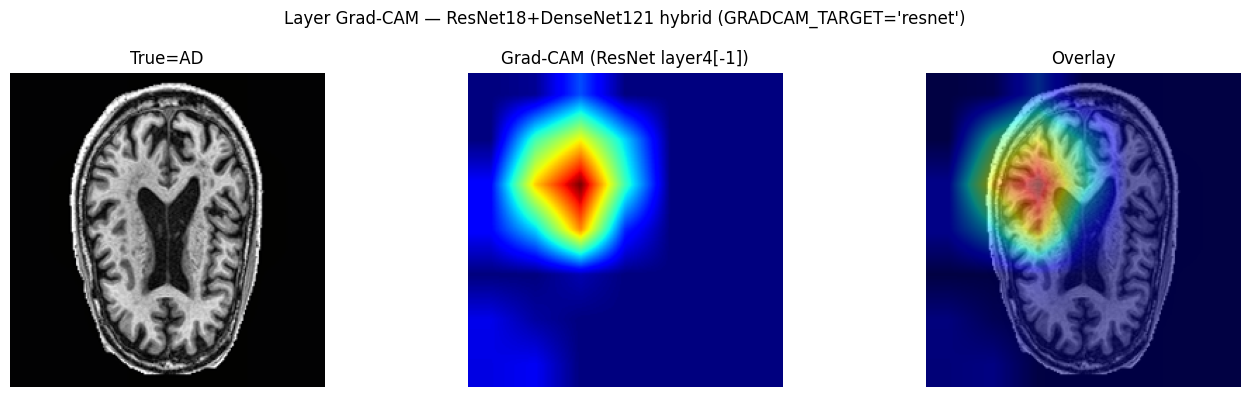

In [83]:
from captum.attr import LayerGradCam

try:
    _tgt = str(GRADCAM_TARGET)
except NameError:
    _tgt = 'resnet'

if _tgt == 'densenet':
    cam_layer = hybrid_model.densenet.features.denseblock4
    cam_label = 'DenseNet denseblock4'
else:
    cam_layer = hybrid_model.resnet.layer4[-1]
    cam_label = 'ResNet layer4[-1]'

hybrid_model.eval()
images_gc, labels_gc = next(iter(test_loader))
images_gc = images_gc.to(device); labels_gc = labels_gc.to(device)
with torch.no_grad():
    pred_gc = hybrid_model(images_gc).argmax(1)
idx_gc = next((i for i in range(images_gc.size(0)) if pred_gc[i] == labels_gc[i]), 0)

xb_gc = images_gc[idx_gc : idx_gc + 1].clone().detach().requires_grad_(True)
yl_gc = labels_gc[idx_gc : idx_gc + 1]

lgc = LayerGradCam(hybrid_model, cam_layer)
cam_attr = lgc.attribute(xb_gc, target=yl_gc)
if isinstance(cam_attr, tuple): cam_attr = cam_attr[0]
ca = cam_attr
if ca.dim() == 4:   cam_map = ca.mean(dim=1, keepdim=True)
elif ca.dim() == 3: cam_map = ca.unsqueeze(1)
else:               cam_map = ca.unsqueeze(0).unsqueeze(0)
cam_map = F.relu(cam_map.float())
cam_map = F.interpolate(cam_map, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False)
cam_np  = cam_map.squeeze().detach().cpu().numpy()
cam_np  = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-8)

mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
std  = np.array(IMAGENET_STD).reshape(3, 1, 1)
rgb_gc  = np.clip(np.transpose(images_gc[idx_gc].detach().cpu().numpy() * std + mean, (1,2,0)), 0, 1)
jet_rgb = mpl_cm.jet(cam_np)[..., :3]
overlay = np.clip(0.48 * rgb_gc + 0.52 * jet_rgb, 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(rgb_gc);   ax[0].set_title(f'True={CLASS_NAMES[labels_gc[idx_gc]]}'); ax[0].axis('off')
ax[1].imshow(cam_np, cmap='jet'); ax[1].set_title(f'Grad-CAM ({cam_label})');      ax[1].axis('off')
ax[2].imshow(overlay);  ax[2].set_title('Overlay');                                ax[2].axis('off')
plt.suptitle(f'Layer Grad-CAM — ResNet18+DenseNet121 hybrid (GRADCAM_TARGET={_tgt!r})')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'gradcam_hybrid.png'), dpi=150)
plt.show()

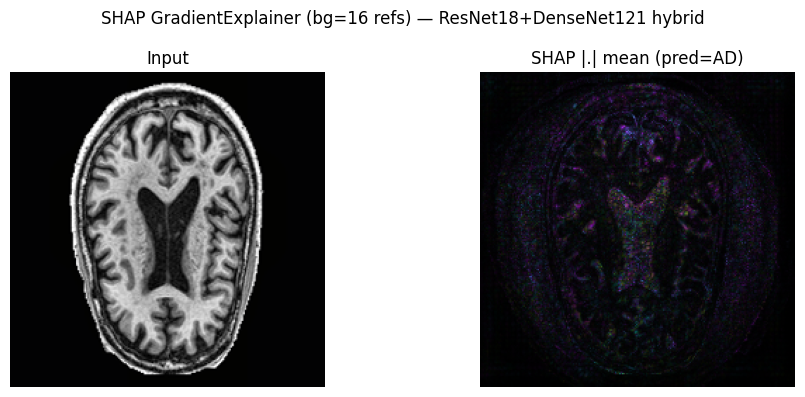

In [84]:
import shap

try:
    _bg_cfg = int(SHAP_BG_SAMPLES)
except NameError:
    _bg_cfg = 16

_n_train   = len(train_ds)
_bg_target = max(2, min(_bg_cfg, _n_train))

hybrid_model.eval()
bg_list, n_bg = [], 0
for xb, _ in train_loader:
    bg_list.append(xb)
    n_bg += xb.size(0)
    if n_bg >= _bg_target:
        break
if not bg_list:
    raise RuntimeError('train_loader returned no batches — run data cells first.')
background = torch.cat(bg_list, 0)[:_bg_target].to(device).float()
if background.size(0) < 2:
    background = torch.cat([background, background], dim=0)

images_sv, _ = next(iter(test_loader))
xt = images_sv[:1].clone().detach().to(device).float().requires_grad_(True)

mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
std  = np.array(IMAGENET_STD).reshape(3, 1, 1)
rgb_sv = np.clip(np.transpose(images_sv[0].detach().cpu().numpy() * std + mean, (1,2,0)), 0, 1)

with torch.no_grad():
    pred_cls = int(hybrid_model(images_sv[:1].to(device)).argmax(1).item())

try:
    explainer = shap.GradientExplainer(hybrid_model, background)
    sv = explainer.shap_values(xt)
    if isinstance(sv, list):
        smap = np.asarray(sv[pred_cls][0])
    else:
        smap = np.asarray(sv[0])
        if smap.ndim == 4 and smap.shape[0] == 1:
            smap = smap[0]
    imp = np.abs(smap).mean(axis=0)
    imp = (imp - imp.min()) / (imp.max() - imp.min() + 1e-8)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(rgb_sv); ax[0].set_title('Input'); ax[0].axis('off')
    ax[1].imshow(imp, cmap='coolwarm')
    ax[1].set_title(f'SHAP |.| mean (pred={CLASS_NAMES[pred_cls]})')
    ax[1].axis('off')
    plt.suptitle(f'SHAP GradientExplainer (bg={background.size(0)} refs) — ResNet18+DenseNet121 hybrid')
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, 'shap_hybrid.png'), dpi=150)
    plt.show()
except Exception as e:
    print(f'SHAP failed: {e}')
    print(f'Hint: n_train={_n_train}, bg_target={_bg_target}. Run config + data cells first.')

  0%|          | 0/100 [00:00<?, ?it/s]

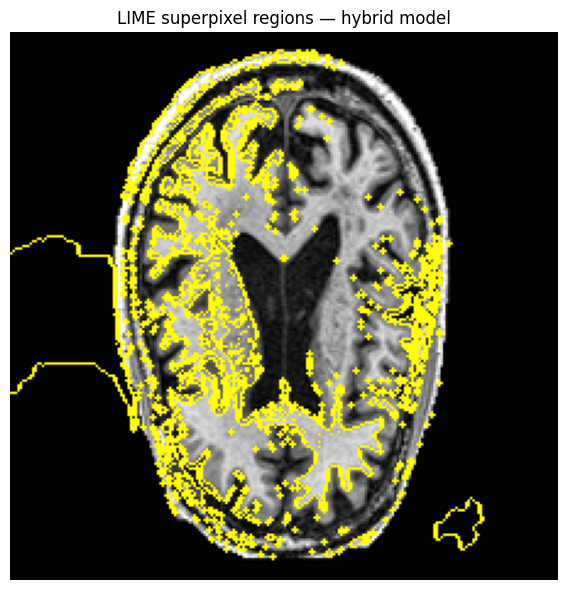

In [85]:
try:
    from lime import lime_image
    from skimage.segmentation import mark_boundaries

    hybrid_model.eval()

    def predict_rgb(rgb_np):
        a = np.asarray(rgb_np, dtype=np.float32)
        if a.ndim == 3: a = a[np.newaxis]
        elif a.ndim != 4:
            raise ValueError(f'LIME predict expected (H,W,C) or (N,H,W,C), got {a.shape}')
        x = torch.from_numpy(a).permute(0,3,1,2).float().to(device) / 255.0
        x = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)(x)
        with torch.no_grad():
            out = hybrid_model(x)
        return torch.softmax(out, 1).cpu().numpy()

    rgb255 = (rgb_ig * 255).astype(np.double)
    ex     = lime_image.LimeImageExplainer()
    exp    = ex.explain_instance(rgb255, predict_rgb, top_labels=len(CLASS_NAMES),
                                 hide_color=0, num_samples=LIME_NUM_SAMPLES, batch_size=32)
    temp, mask = exp.get_image_and_mask(exp.top_labels[0],
                                        positive_only=True, num_features=10, hide_rest=False)
    plt.figure(figsize=(6, 6))
    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.title('LIME superpixel regions — hybrid model')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, 'lime_hybrid.png'), dpi=120)
    plt.show()
except Exception as e:
    print(f'LIME skipped: {e}')